# Tradução com FLAN-T5-Large
Notebook estruturado com tradução, BLEU e gráfico.

In [ ]:
!pip install sacrebleu
!pip install transformers
!pip install sentencepiece
!pip install matplotlib

  Using cached sacrebleu-2.5.1-py3-none-any.whl.metadata (51 kB)
  Using cached portalocker-3.2.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 1.9 MB/s eta 0:00:00


In [ ]:
import re
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import sacrebleu
import torch

## Texto italiano

In [ ]:
TEXTO_ITALIANO = """
Proémio, n. 1
"Il sacro Concilio, udendo con religiosa attenzione la parola di Dio e proclamandola con ferma fiducia, fa sue queste parole di san Giovanni: «Vi annunziamo la vita eterna, que era presso il Padre e si manifestò a noi: vi annunziamo ciò che abbiamo veduto e udito, affinché anche voi siate in comunione con noi, e la nostra comunione sia col Padre e col Figlio suo Gesù Cristo» (1 Gv 1,2-3)."

"Perciò, seguindo i Concili Tridentino e Vaticano I, esso intende proporre l'autentica dottrina sulla divina Rivelazione e sulla sua trasmissione, affinché, per l'annunzio della salvezza, il mondo intero ascoltando creda, credendo speri, sperando ami."

Capítulo I, n. 2
"Piacque a Dio nella sua bontà e sapienza rivelare se stesso e far conoscere il mistero della sua volontà (cfr. Ef 1,9), mediante il quale gli uomini per mezzo di Cristo, Verbo fatto carne, nello Spirito Santo hanno accesso al Padre e sono resi partecipi della divina natura (cfr. Ef 2,18; 2 Pt 1,4)."

"Con questa rivelazione infatti, Dio invisibile (cfr. Col 1,15; 1 Tm 1,17) nel suo immenso amore parla agli uomini come ad amici (cfr. Es 33,11; Gv 15,14-15) e si intrattiene con essi (cfr. Bar 3,38), per invitarli e ammetterli alla comunione con sé."

"Questa «economia» della Rivelazione avviene con eventi e parole intimamente connessi tra loro, in modo che le opere, compiute da Dio nella storia della salvezza, manifestano e rafforzano la dottrina e le realtà significate dalle parole, e le parole a loro volta proclamano le opere e chiariscono il mistero in esse contenuto."

"Però la profonda verità, sia riguardo a Dio, sia riguardo alla salvezza degli uomini, per mezzo di questa Rivelazione, risplende a noi in Cristo, che è insieme il mediatore e la pienezza di tutta intera la Rivelazione (2)."

Capítulo I, n. 3
"Dio, il quale crea e conserva tutte le cose per il Verbo (cfr. Gv 1,3), offre agli uomini nelle cose create una perenne testimonianza di sé (cfr. Rm 1,19-20). Inoltre, volendo aprire la via della salvezza soprannaturale, fin dal principio manifestò se stesso ai Progenitori."

"Dopo la loro caduta, con la promessa della redenzione, li sollevò alla speranza della salvezza (cfr. Gn 3,15), e senza interruzione ebbe cura del genere umano, per dare la vita eterna a tutti coloro que cercano la salvezza con la perseveranza nelle buone opere (cfr. Rm 2,6-7)."

"A suo tempo chiamò Abramo, per fare di lui un popolo grande (cfr. Gn 12,2), popolo che dopo i Patriarchi istruì per mezzo di Mosè e dei profeti, affinché lo riconoscesse come l'unico Dio vivo e vero, padre provvido e giusto giudice, e attendesse il Salvatore promesso; e così preparò attraverso i secoli la via al Vangelo."

Capítulo I, n. 4
"Dopo aver a più riprese e in più modi parlato per mezzo dei profeti, « Dio ultimamente, in questi giorni, ha parlato a noi per mezzo del Figlio » (Eb 1,1-2)."

"Ha mandato infatti il Figlio suo, cioè il Verbo eterno, que illumina tutti gli uomini, affinché dimorasse tra gli uomini e ad essi spiegasse l'intimo di Dio (cfr. Gv 1,1-18)."

"Gesù Cristo, Verbo fatto carne, mandato come «uomo agli uomini» (3), «parla le parole di Dio» (Gv 3,34) e porta a compimento l'opera di salvezza que il Padre gli aveva affidato (cfr. Gv 5,36; 17,4)."

"Perciò chi vede lui, vede anche il Padre (cfr. Gv 14,9). Egli, con tutta la sua presenza e manifestazione, con le parole e con le opere, con i segni e con i miracoli, e specialmente con la sua morte e gloriosa risurrezione, e infine con l'invio dello Spirito di verità, compie e completa la Rivelazione e la conferma con la testimonianza divina, ossia che Dio è con noi per liberarci dalle tenebre del peccato e della morte e per risuscitarci a vita eterna."

"Per questo l'Economia cristiana, in quanto Alleanza nuova e definitiva, non passerà mai, e non si dovrà attendere nessun'altra rivelazione pubblica prima della manifestazione gloriosa del Signore nostro Gesù Cristo (cfr. 1 Tm 6,14; Tt 2,13)."

Capítulo I, n. 5
"A Dio che rivela è dovuta «l'obbedienza della fede» (Rm 16,26; cfr. Rm 1,5; 2 Cor 10,5-6)."

"Con la fede infatti l'uomo si abbandona interamente a Dio liberamente, prestando «con l'intelletto e con la volontà l'ossequio pieno a Dio che rivela» (4) e dando il suo assenso volontario alla rivelazione fatta da lui."

"Per prestare questa fede, é necessaria la grazia di Dio che previene e soccorre, e gli aiuti interiori dello Spirito Santo, il quale muova il cuore e lo rivolga a Dio, apra gli occhi della mente e dia «a tutti soavità nel consentire e nel credere alla verità» (5)."

"Affinché l'intelligenza della Rivelazione diventi sempre più profonda, lo stesso Spirito Santo perfeziona continuamente la fede per mezzo dei suoi doni."

Capítulo I, n. 6
"Con la divina Rivelazione Iddio volle manifestare e comunicare se stesso e i decreti della sua volontà per la salvezza degli uomini, «per renderli cioè partecipi dei beni divini, che trascendono assolutamente l'intelligenza della mente umana» (6)."

"Il santo Concilio professa que «Dio, principio e fine di tutte le cose, può essere conosciuto con certezza con la luce naturale della ragione umana a partire dalle cose create» (cfr. Rm 1,20);"

"ma insegna pure che è merito della Rivelazione divina se «tutto ciò que nelle cose divine non è per sé inaccessibile alla ragione umana, può, anche nell'attuale condizione del genere umano, essere conosciuto da tutti facilmente, con ferma certezza e senza mescolanza di errore» (7)."

Capítulo II, n. 7
"Dio con somma benignità dispose che quanto Egli aveva rivelato per la salvezza di tutte le genti, rimanesse per sempre integro e venisse trasmesso a tutte le generazioni."

"Perciò Cristo Signore, nel quale si compie tutta intera la Rivelazione del sommo Dio (cfr. 2 Cor 1,20; 3,16-4,6), dopo aver portato a compimento in sé tutta la verità de Dio predicò di persona (1), comandò agli apostoli che predicassero a tutti, come la fonte di ogni verità salutare e di ogni regola morale, quel Vangelo che egli prima aveva promesso per mezzo dei profeti e que poi aveva adempiuto e promulgato di persona, comunicando così ad essi i doni divini."

"Questo venne fedelmente eseguito, sia dagli apostoli, i quali nella predicazione orale, con gli esempi e le istituzioni trasmisero sia ciò che avevano ricevuto dalla bocca del Cristo vivendo con lui e osservandolo agire, sia ciò che avevano imparato dai suggerimenti dello Spirito Santo, sia da quegli apostoli o da uomini della loro cerchia, i quali, per ispirazione dello stesso Spirito Santo, misero per iscritto il messaggio della salvezza (2)."

"Gli apostoli poi, affinché il Vangelo si conservasse sempre integro e vivo nella Chiesa, lasciarono come loro successori i vescovi, ad essi «affidando il loro proprio posto di maestri» (3)."

"Questa sacra Tradizione e la sacra Scrittura di entrambi i Testamenti sono dunque come uno specchio nel quale la Chiesa pellegrina in terra contempla Dio, dal quale tutto riceve, finché giunga a vederlo faccia a faccia, com'egli è (cfr. 1 Gv 3,2)."

Capítulo II, n. 8
"Così la predicazione apostolica, che è espressa in modo speciale nei libri ispirati, doveva con una successione ininterrotta conservarsi sino alla fine dei tempi."

"Perciò gli apostoli, trasmettendo ciò che essi stessi avevano ricevuto, ammoniscono i fedeli ad attenersi alle tradizioni che avevano appreso o con la parola, o per scritto (cfr. 2 Ts 2,15), e a combattere per la fede che ad essi era stata trasmessa una volta per tutte (cfr. Gd 3)(4)."

"Ora, ciò que fu trasmesso dagli apostoli, comprende tutto quanto contribuisce alla santità di vita e al incremento della fede nel popolo di Dio; e così la Chiesa, nella sua dottrina, nella sua vita e nel suo culto, perpetua e trasmette a tutte le generazioni tutto ciò che essa è, tutto ciò che essa crede."

"Questa Tradizione, che trae origine dagli apostoli, progredisce nella Chiesa con l'assistenza dello Spirito Santo (5)."

"Cresce infatti la comprensione, tanto delle cose quanto delle parole trasmesse, sia con la contemplazione e lo studio dei credenti, che le meditano in cuor loro (cfr. Lc 2,19 e 51), sia con l'intelligenza interiore, che essi provano delle cose spirituali, sia per la predicazione di coloro i quali con la successione episcopale hanno ricevuto un carisma sicuro di verità."

"La Chiesa cioè, nel corso dei secoli, tende incessantemente alla pienezza della verità divina, finché in essa giungano a compimento le parole di Dio."

"Le asserzioni dei santi Padri attestano la presenza vivificatrice di questa Tradizione, i cui tesori si riversano nella pratica e nella vita della Chiesa credente e orante."

"Per mezzo di questa medesima Tradizione la Chiesa conosce il canone completo dei libri sacri, e le stesse sacre Scritture in essa vengono comprese più profondamente e rese incessantemente operanti;"

"e così Dio, il quale parlò nel passato, non cessa di conversare con la Sposa del suo Figlio diletto;"

"e lo Spirito Santo, per mezzo del quale la voce viva del Vangelo risuona nella Chiesa, e per mezzo di questa nel mondo, introduce i credenti in tutta intera la verità e fa sì che in essi risieda abbondantemente la parola di Cristo (cfr. Col 3,16)."

Capítulo II, n. 9
"La sacra Tradizione e la sacra Scrittura sono dunque strettamente connesse e comunicanti tra loro."

"Infatti, ambedue scaturiscono dalla medesima sorgente divina, formano in certo qual modo una cosa sola e tendono allo stesso fine."

"La sacra Scrittura infatti è la parola di Dio in quanto è messa per iscritto sotto l'ispirazione dello Spirito divino."

"Quanto alla sacra Tradizione, essa trasmette integralmente la parola di Dio, affidata da Cristo Signore e dallo Spirito Santo agli Apostoli, ai loro successori, affinché questi, illuminati dallo Spirito di verità, nella loro predicazione la conservino fedelmente, la espongano e la diffondano."

"Ne consegue che la Chiesa non attinge la certezza su tutte le cose rivelate dalla sola sacra Scrittura."

"Perciò l'una e l'altra devono essere accettate e venerate con pari sentimento di pietà e di riverenza (6)."

Capítulo II, n. 10
"La sacra Tradizione e la sacra Scrittura costituiscono un solo sacro deposito della parola di Dio affidato alla Chiesa;"

"nell'aderire ad esso, tutto il popolo santo, unito ai suoi Pastori, persevera costante nell'insegnamento degli Apostoli e nella comunione, nella frazione del pane e nella preghiera (cfr. At 2,42 gr.), in modo che nel ritenere, praticare e professare la fede trasmessa, si crei una singolare concordia di vescovi e di fedeli (7)."

"L'ufficio poi d'interpretare autenticamente la parola di Dio scritta o trasmessa, è affidato al solo Magistero vivo della Chiesa (8), la cui autorità è esercitata nel nome di Gesù Cristo (9)."

"Il Magistero, tuttavia, non è superior alla parola di Dio, ma la serve, insegnando soltanto ciò que é stato trasmesso, in quanto, per divino mandato e con l'assistenza dello Spirito Santo, piamente la ascolta, santamente la custodisce e fedelmente la espone, attingendo da questo unico deposito della fede tutto ciò che propone da credere come divinamente rivelato."

"È chiaro dunque che la sacra Tradizione, la sacra Scrittura e il Magistero della Chiesa, per sapientissima disposizione di Dio, sono tra loro così connessi e congiunti che nessuno d'essi sussiste senza gli altri, e tutti insieme, ciascuno a suo modo, sotto l'azione dello Spirito Santo, contribuiscono efficacemente alla salvezza delle anime."

Capítulo III, n. 11
"Le verità divinamente rivelate, che nei libri della sacra Scrittura sono contenute ed espresse, furono scritte per ispirazione dello Spirito Santo."

"La santa Madre Chiesa, secondo la fede degli Apostoli, ritiene sacri e canonici tutti i libri sia dell'Antico che del Nuovo Testamento con tutte le loro parti, perché scritti per ispirazione dello Spirito Santo (cfr. Gv 20,31; 2 Tm 3,16; 2 Pt 1,19-21; 3,15-16), hanno Dio per autore e como tali sono stati affidati alla Chiesa stessa (1)."

"Per la composizione dei libri sacri, Dio scelse degli uomini di cui si servì nel possesso delle loro facoltà e capacità, affinché, agendo egli in essi e per essi (2), scrivessero come veri autori, tutte e soltanto quelle cose che Egli voleva (3)."

"Poiché dunque tutto quello che gli autori ispirati o agiografi asseriscono è da ritenersi asserito dallo Spirito Santo, ne consegue que i libri della Scrittura insegnano con certezza, fedelmente e senza errore la verità que Dio per la nostra salvezza volle fosse consegnata nelle sacre Lettere (4)."

"Perciò «tutta la Scrittura è ispirata da Dio e utile per insegnare, per convincere, per correggere, per educare alla giustizia, affinché l'uomo di Dio sia perfetto, pronto per ogni opera buona» (2 Tm 3,16-17 gr.)."

Capítulo III, n. 12
"Dio nella sacra Scrittura ha parlato per mezzo di uomini e alla maniera umana (5). Per l'interprete della sacra Scrittura, dunque, per conoscere ciò que Dio ha voluto comunicarci, bisogna ricercare con attenzione che cosa gli agiografi abbiano veramente voluto significare e a Dio sia piaciuto manifestare con le loro parole."

"Per scoprire l'intenzione degli agiografi, si deve tener conto tra l'altro anche dei «generi letterari»."

"La verità infatti viene diversamente proposta ed espressa in testi in vario modo storici, o profetici, o poetici, o in altri modi di dire."

"È necessario che l'interprete ricerchi il senso che l'agiografo in determinate circostanze, secondo le condizioni del suo tempo e della sua cultura, e servendosi dei generi letterari allora in uso, intendeva esprimere e di fatto espresse (6)."

"Per comprendere infatti esattamente ciò che l'autore sacro volle asserire, si deve tener conto convenientemente sia dei modi nativi di sentire, di esprimersi e di raccontare vigenti al tempo dell'agiografo, sia di quelli che in quel tempo erano abitualmente in uso nei rapporti umani (7)."

"Ma poiché la sacra Scrittura deve essere letta e interpretata con lo stesso Spirito col quale fu scritta (8), per ricavarne con esattezza il senso dei testi sacri, si deve badare con non minore diligenza al contenuto e alla unità di tutta la Scrittura, tenuto debito conto della viva Tradizione di tutta la Chiesa e dell'analogia della fede."

"È compito degli esegeti lavorare secondo queste regole, per una più profonda intelligenza ed esposizione del senso della sacra Scrittura, affinché per mezzo di studi in qualche modo preparatori, maturi il giudizio della Chiesa."

"Tutto ciò infatti che concerne il modo di interpretare la Scrittura, è sottoposto in ultima istanza al giudizio della Chiesa, la quale adempie il divino mandato e ministero di custodire e interpretare la parola di Dio (9)."

Capítulo III, n. 13
"Pertanto nella sacra Scrittura, ferma restando la verità e la santità di Dio, si manifesta la mirabile «condiscendenza» della Sapienza eterna, «perché impariamo quale ineffabile benignità di Dio e"

"quanta sollecitudine Egli abbia avuto per la nostra natura» (10)."

"Le parole di Dio infatti, espresse con lingue umane, si sono fatte simili al parlare umano, così come già il Verbo dell'eterno Padre, avendo assunto la carne dell'umana debolezza, divenne simile agli uomini."

Capítulo IV, n. 14
"Dio con sommo amore, volendo e preparando la salvezza di tutto il genere umano, con singolare disegno si scelse un popolo, al quale affidare le sue promesse."

"Dopo aver stabilito un'alleanza con Abramo (cfr. Gn 15,18), e per mezzo di Mosè con il popolo d'Israele (cfr. Es 24,8), a questo popolo eletto si rivelò come l'unico Dio vivo e vero, in modo que Israele potesse conoscere per esperienza il piano di Dio nei riguardi degli uomini, e lo comprendesse con chiarezza e sempre più a fondo attraverso la parola dello stesso Dio que parlava per bocca dei profeti, e lo diffondesse in modo più ampio tra le genti (cfr. Sal 21,28-29; 95,1-3; Is 2,1-4; Ger 3,17)."

"L'economia della salvezza, annunziata in precedenza, narrata e spiegata dagli autori sacri, si incontra nei libri dell'Antico Testamento come vera parola di Dio."

"Per questo tali libri divinamente ispirati conservano un valore perenne: «Tutto ciò infatti che fu scritto, fu scritto per nostra istruzione, affinché mediante la pazienza e la consolazione delle Scritture, avessimo la speranza» (Rm 15,4)."

Capítulo IV, n. 15
"L'economia dell'Antico Testamento era soprattutto ordinata a preparare, ad annunziare profeticamente (cfr. Lc 24,44; Gv 5,39; 1 Pt 1,10) e a significare con varie figure (cfr. 1 Cor 10,11) l'avvento di Cristo, redentore universale, e del regno messianico."

"I libri dell'Antico Testamento, secondo la condizione del genere umano prima del tempo della salvezza attuata da Cristo, manifestano a tutti la conoscenza di Dio e dell'uomo e i modi con cui Dio giusto e misericordioso tratta gli uomini."

"Questi libri, sebbene contengano anche cose imperfette e caduche, dimostrano tuttavia una vera pedagogia divina (1)."

"Perciò i fedeli devono accogliere con devozione questi libri, i quali esprimono il vivo senso di Dio, e nei quali si trovano sublimi dottrine su Dio, salutari insegnamenti sulla vita dell'uomo e mirabili tesori di orazioni, e finalmente nei quali è nascosto il mistero della nostra salvezza."

Capítulo IV, n. 16
"Perciò Dio, l'ispiratore e l'autore dei libri dell'uno e dell'altro Testamento, ha sapientemente disposto che il Nuovo fosse nascosto nell'Antico e l'Antico fosse svelato nel Nuovo (2)."

"Quantunque infatti Cristo abbia fondato la Nuova Alleanza nel suo sangue (cfr. Lc 22,20; 1 Cor 11,25), tuttavia i libri dell'Antico Testamento, integralmente assunti nella predicazione evangelica (3), acquistano e manifestano il loro pieno significato nel Nuovo Testamento (cfr. Mt 5,17; Lc 24,27; Rm 16,25-26; 2 Cor 3,14-16), que essi a loro volta illuminano e spiegano."

Capítulo V, n. 17
"La parola di Dio, che è potenza di Dio per la salvezza di chiunque crede (cfr. Rm 1,16), si presenta ed manifesta la sua forza in modo eminente negli scritti del Nuovo Testamento."

"Quando infatti venne la pienezza dei tempi (cfr. Gal 4,4), il Verbo si fece carne e abitò tra noi pieno di grazia e di verità (cfr. Gv 1,14)."

"Cristo stabilì il regno di Dio sulla terra, manifestò con opere e parole il Padre suo e se stesso, e portò a compimento l'opera sua con la morte, la risurrezione e la gloriosa ascensione, e con l'invio dello Spirito Santo."

"Elevato da terra, egli attira tutti a sé (cfr. Gv 12,32 gr.), lui que solo ha parole di vita eterna (cfr. Gv 6,68)."

"Questo mistero però non fu palesato alle altre generazioni, come ora è stato rivelato ai suoi santi apostoli e ai profeti nello Spirito Santo (cfr. Ef 3,4-6 gr.), affinché predicassero l'Evangelo, suscitassero la fede in Gesù Cristo Signore e raccogliessero la Chiesa."

"Di tutte queste cose gli scritti del Nuovo Testamento presentano una testimonianza perenne e divina."

Capítulo V, n. 18
"A nessuno sfugge che tra tutte le Scritture, anche del Nuovo Testamento, i Vangeli possiedono una meritata superiorità, in quanto costituiscono la principale testimonianza relativa alla vita e alla dottrina del Verbo incarnato, nostro Salvatore."

"La Chiesa ha ritenuto e ritiene sempre e in ogni luogo che i quattro Vangeli sono di origine apostolica."

"Infatti, ciò che gli apostoli per mandato di Cristo predicarono, in seguito, per ispirazione dello Spirito Santo, fu dagli stessi e da uomini della loro cerchia tramandato in scritti, que sono il fondamento della fede, cioè l'Evangelo quadriforme secondo Matteo, Marco, Luca e Giovanni (1)."

Capítulo V, n. 19
"La santa Madre Chiesa ha ritenuto e ritiene con fermezza e con la massima costanza che i quattro Vangeli, di cui afferma senza esitazione la storicità, trasmettono fedelmente le cose che Gesù Figlio di Dio, durante la sua vita tra gli uomini, effettivamente operò e insegnò per la loro salvezza eterna, fino al giorno in cui fu assunto in cielo (cfr. At 1,1-2)."

"Gli apostoli poi, dopo l'Ascensione del Signore, trasmisero ai loro uditori ciò che egli aveva detto e fatto, con quella più completa intelligenza delle cose, di cui essi, istruiti dagli eventi gloriosi di Cristo e illuminati dallo Spirito di verità (2), godevano (3)."

"Gli autori sacri, poi, scrissero i quattro Vangeli, scegliendo alcune cose tra le molte tramandate a voce o già per iscritto, facendone una sintesi, o spiegandole avuto riguardo alla situazione delle Chiese, conservando infine il carattere di predicazione, sempre però in modo da riferire su Gesù cose vere e sincere (4)."

"Essi infatti, attingendo sia dai propri ricordi sia dalla testimonianza di quelli «che fin dal principio furono testimoni oculari e ministri della parola», scrissero con l'intenzione di farci conoscere la «verità» (cfr. Lc 1,2-4) degli insegnamenti che abbiamo ricevuto."

Capítulo V, n. 20
"Il canone del Nuovo Testamento, oltre ai quattro Vangeli, contiene anche le lettere di san Paolo e altri scritti apostolici, composti per ispirazione dello Spirito Santo; questi scritti, per saggia disposizione di Dio, confermano tutto ciò che riguarda Cristo Signore, spiegano ulteriormente la sua autentica dottrina, fanno conoscere la potenza salvifica dell'opera divina di Cristo, narrano gli inizi della Chiesa e la sua mirabile diffusione nel mondo e preannunziano la sua gloriosa consumazione."

"Il Signore Gesù infatti assistette i suoi apostoli como aveva promesso (cfr. Mt 28,20) e inviò loro lo Spirito consolatore, il quale li doveva introdurre nella pienezza della verità (cfr. Gv 16,13)."

Capítulo VI, n. 21
"La Chiesa ha sempre venerato le divine Scritture come venera lo stesso Corpo di Cristo, non mancando mai, soprattutto nella sacra Liturgia, di nutrirsi del pane di vita della mensa sia della parola di Dio que del Corpo di Cristo, e di porgerlo ai fedeli."

"Le ha sempre considerate, e le considera tuttora, insieme con la sacra Tradizione, come regola suprema della propria fede; esse infatti, ispirate come sono da Dio e redatte una volta per sempre, comunicano in modo immutabile la parola dello stesso Dio, e fanno risuonar nelle parole dei profeti e degli apostoli la voce dello Spirito Santo."

"È necessario perciò que tutta la predicazione ecclesiastica, come la stessa religione cristiana, sia nutrita e regolata dalla sacra Scrittura."

"Nei libri sacri, infatti, il Padre que è nei cieli viene con molta amorevolezza incontro ai suoi figli e entra in conversazione con essi;"

"nella parola di Dio poi è insita una così grande efficacia e potenza, da essere sostegno e vigore della Chiesa, e per i figli della Chiesa la forza della loro fede, il nutrimento dell'anima, la sorgente pura e perenne della vita spirituale."

"Perciò si devono riferire in modo tutto speciale alla sacra Scrittura le parole: «Viva ed efficace è la parola di Dio» (Eb 4,12), «que ha il potere di edificare e di dare l'eredità con tutti i santificati» (At 20,32; cfr. 1 Ts 2,13)."

Capítulo VI, n. 22
"È necessario che i fedeli abbiano largo accesso alla sacra Scrittura."

"Per questo motivo la Chiesa fin dai suoi inizi ha fatto sua l'antichissima traduzione greca del Vecchio Testamento, detta dei Settanta, e tiene sempre in onore le altre versioni orientali e le versioni latine, particolarmente quella che è chiamata Vulgata."

"Poiché però la parola di Dio deve essere a disposizione di tutti in ogni tempo, la Chiesa con materna sollecitudine cura que si facciano traduzioni appropriate e corrette nelle varie lingue, di preferenza dai testi originali dei sacri libri."

"Se, per una ragione di opportunità e con l'approvazione dell'autorità della Chiesa, queste traduzioni vengono fatte in collaborazione con i fratelli separati, potranno essere usate da tutti i cristiani."

Capítulo VI, n. 23
"La Sposa del Verbo incarnato, la Chiesa, istruita dallo Spirito Santo, si preoccupa di raggiungere una intelligenza sempre più profonda delle sacre Scritture, per poter nutrire continuamente i suoi figli con le divine parole; perciò essa favorisce con ragione anche lo studio dei santi Padri del Oriente e dell'Occidente e delle sacre liturgie."

"Gli esegeti cattolici, e gli altri cultori di sacra teologia, collaborando con zelo e sotto la vigilanza del sacro magistero, si adoperino per studiare e spiegare con gli opportuni sussidi le divine Lettere, in modo que il maggior numero possibile di ministri della parola divina siano in grado di offrire con frutto al popolo di Dio il nutrimento delle Scritture, que illumini la mente, corrobori le volontà e accenda i cuori degli uomini all'amore di Dio (1)."

"Il santo Concilio incoraggia i figli della Chiesa que coltivano le scienze bibliche, a che continuino fino alla fine il lavoro felicemente intrapreso con ardore sempre rinnovato e secondo il senso della Chiesa (2)."

Capítulo VI, n. 24
"La sacra teologia si basa come su un fondamento perenne sulla parola di Dio scritta, inseparabile dalla sacra Tradizione; in essa si consolida vigorosamente e si ringiovanisce sempre, scrutando alla luce della fede ogni verità racchiusa nel mistero di Cristo."

"Le sacre Scritture contengono la parola di Dio e, perché ispirate, sono veramente parola di Dio, sia perciò lo studio delle sacre pagine come l'anima della sacra teologia (3)."

"Anche il ministero della parola, ossia la predicazione pastorale, la catechesi e ogni tipo d'istruzione cristiana, in cui l'omelia liturgica deve avere un posto privilegiado, trova in questa stessa parola della Scrittura un alimento sano e un santo vigore."

Capítulo VI, n. 25
"È necessario perciò che tutti i chierici, e soprattutto i sacerdoti di Cristo e gli altri que, come i diaconi e i catechisti, attendono legittimamente al ministero della parola, conservino un contatto continuo con le Scritture mediante una spirituale lettura assidua e uno studio accurato, affinché non diventi «un vano predicatore della parola di Dio all'esterno colui che non l'ascolta dentro di sé» (4), mentre deve partecipare ai fedeli a lui affidati le soverchianti ricchezze della parola divina, specialmente nella sacra Liturgia."

"Egualmente il santo Concilio esorta con ardore e insistenza tutti i fedeli, soprattutto i religiosi, ad apprendere «la sublime scienza di Gesù Cristo» (Fil 3,8) con la frequente lettura delle divine Scritture. «L'ignoranza delle Scritture infatti è ignoranza di Cristo» (5)."

"Accostino essi di buon grado il sacro testo, sia mediante la sacra Liturgia, che è impregnata di parole divine, sia mediante la pia lettura, sia per mezzo delle iniziative adatte a tale scopo e di altri sussidi, que con l'approvazione e la cura dei Pastori della Chiesa, lodevolmente oggi si diffondono dappertutto."

"Si ricordino però que la lettura della sacra Scrittura deve essere accompagnata dalla preghiera, affinché si stabilisca il colloquio tra Dio e l'uomo; poiché «a lui parliamo quando preghiamo; lui ascoltiamo, quando leggiamo gli oracoli divini» (6)."

"Compete ai sacri Pastori, «depositari della dottrina apostolica» (7), istruire opportunamente i fedeli ad essi affidati sul retto uso dei libri divini, in modo particolare del Nuovo Testamento e in primo luogo dei Vangeli."

"E ciò per mezzo di traduzioni dei sacri testi; queste devono essere munite delle note necessarie e veramente sufficienti, affinché i figli della Chiesa si familiarizzino con sicurezza e profitto con le sacre Scritture e s'imbevano del loro spirito."

"Inoltre, si preparino edizioni della sacra Scrittura fornite di idonee annotazioni, per uso anche dei non cristiani e adattate alla loro situazione; sia i Pastori d'anime, sia i cristiani di qualsiasi stato avranno cura di diffonderle con zelo e prudenza."

Capítulo VI, n. 26
"In tal modo dunque, con la lettura e lo studio dei sacri libri « la parola di Dio compia la sua corsa e sia glorificata» (2 Ts 3,1), e il tesouro della rivelazione, affidato alla Chiesa, riempa sempre più il cuore degli uomini."

"Come dall'assidua frequenza del mistero eucaristico si accresce la vita della Chiesa, così è lecito sperare nuovo impulso alla vita spirituale dall'accresciuta venerazione per la parola di Dio, que «permane in eterno» (Is 40,8; cfr. 1 Pt 1,23-25)."
"""

## Tradução FLAN-T5-Large

In [ ]:
try:
    model_name = "google/flan-t5-large"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")
    # Try to use memory-saving options when available
    load_kwargs = {}
    # If GPU available, request fp16 and low_cpu_mem_usage for faster/memory-efficient load
    if device == "cuda":
        try:
            model = AutoModelForSeq2SeqLM.from_pretrained(model_name, torch_dtype=torch.float16, low_cpu_mem_usage=True)
        except Exception as e:
            print("fp16/low_cpu_mem_usage failed, falling back to default load:", e)
            model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    else:
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model.to(device)
    print("Model and tokenizer loaded successfully.")
    # quick test
    input_text = "Summarize: Machine learning models can be large."
    inputs = tokenizer(input_text, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=50)
    print("Test output:", tokenizer.decode(out[0], skip_special_tokens=True))
except Exception as err:
    print("Error while loading Flan-T5 model:", err)
    print("Make sure 'transformers' and 'torch' are installed and you have enough memory.")

Device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Model and tokenizer loaded successfully.
Test output: Understand that machine learning models can be large.


## BLEU

In [ ]:
from transformers import pipeline

# Inicializa a pipeline de tradução usando o modelo, tokenizer e device carregados.
# 'model', 'tokenizer' e 'device' estão disponíveis da célula 'eabe5006'.
translator = pipeline("text2text-generation", model=model, tokenizer=tokenizer, device=device)

# Prepara o texto de entrada para tradução. FLAN-T5 geralmente requer um prefixo específico.
input_text_for_translation = "translate Italian to Portuguese: " + TEXTO_ITALIANO

# Realiza a tradução.
# max_new_tokens é definido para um valor suficientemente alto para acomodar o comprimento do texto traduzido.
# truncation=True lida com casos em que o texto de entrada é muito longo para a janela de contexto do modelo.
translation_output = translator(input_text_for_translation, max_new_tokens=4096, truncation=True)

# Extrai o texto traduzido do output da pipeline (CORREÇÃO: usa 'generated_text')
traducao = translation_output[0]['generated_text']

# Calcula o score BLEU. ATENÇÃO: Está comparando a tradução (Português) com o texto de origem (Italiano).
# Para um score de qualidade de tradução real, a referência (segundo argumento) deveria ser o texto 'gold standard' em Português.
bleu_score = sacrebleu.corpus_bleu([traducao], [[TEXTO_ITALIANO]])
bleu_score

Device set to use cpu


BLEU = 0.00 81.1/60.8/47.8/40.9 (BP = 0.000 ratio = 0.041 hyp_len = 228 ref_len = 5588)

## Gráfico

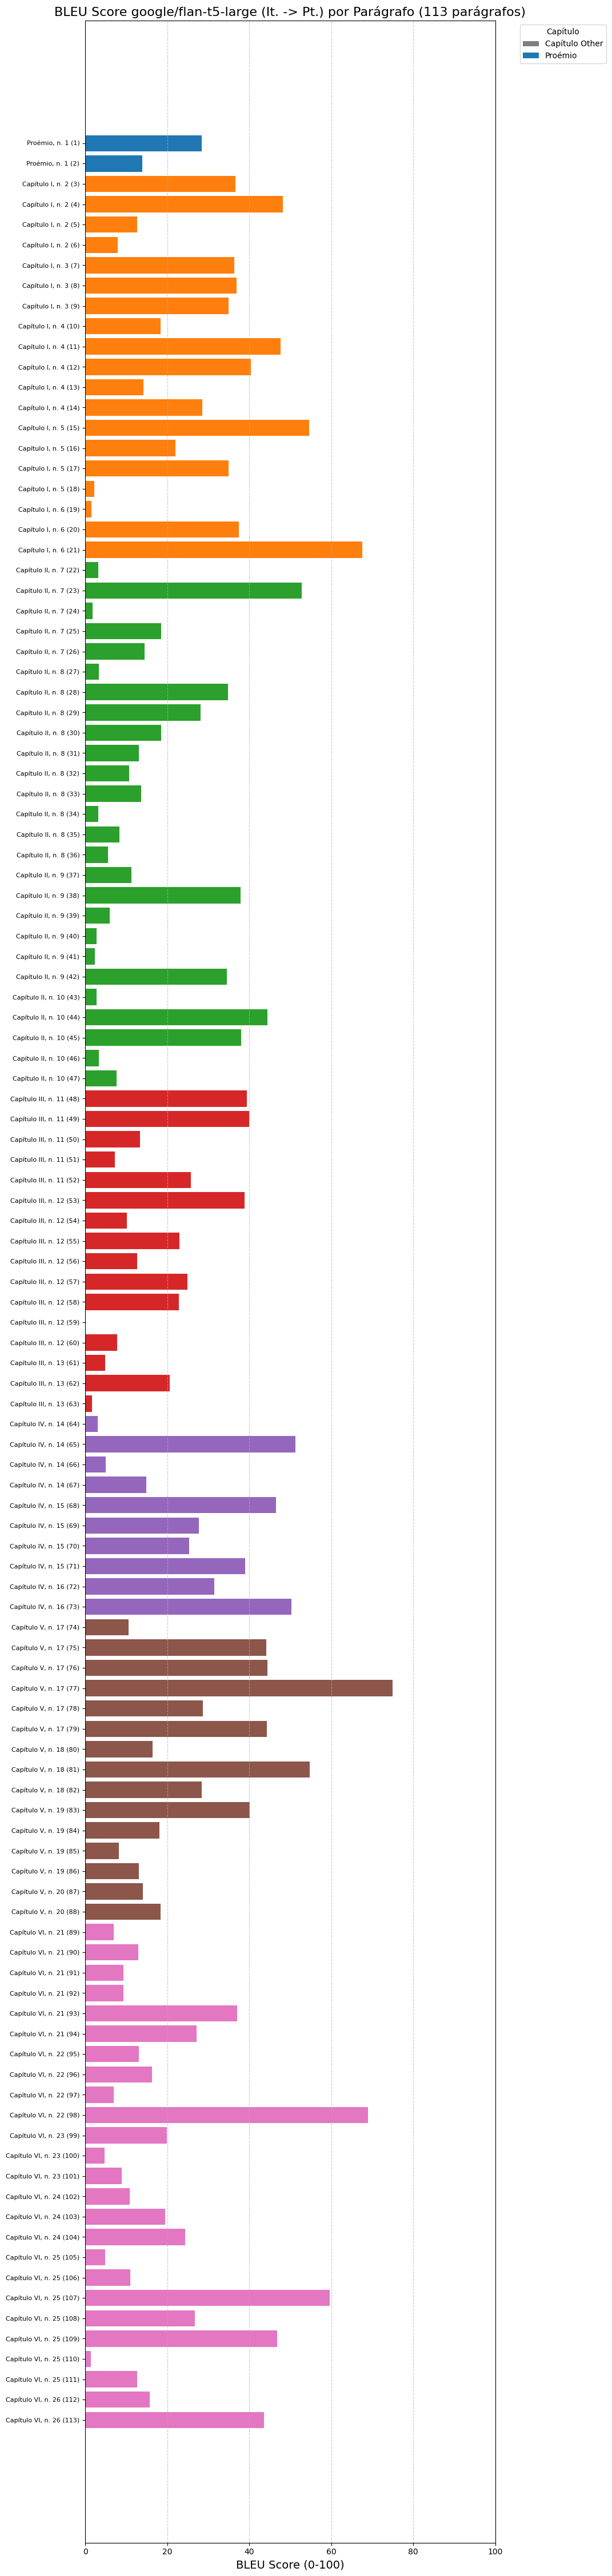

In [ ]:
# 1. Divide TEXTO_ITALIANO em parágrafos e títulos
def process_text_for_plotting(text):
    titles_for_plot = []
    paragraphs_for_plot = []

    # Padrão regex para capturar o título da seção e o bloco de conteúdo subsequente (incluindo quebras de linha)
    # até o próximo título de seção ou o fim do texto. re.DOTALL é crucial.
    pattern = re.compile(r'(Proémio, n\. \d+|Capítulo \w+, n\. \d+)\s*(.*?)(?=(Proémio, n\. \d+|Capítulo \w+, n\. \d+)|$)', re.DOTALL)

    for match in pattern.finditer(text):
        current_section_title = match.group(1).strip()
        content_block = match.group(2).strip()

        # Divide o bloco de conteúdo em parágrafos individuais entre aspas
        quoted_paragraphs = re.findall(r'"(.*?)"', content_block, re.DOTALL)

        for para_content in quoted_paragraphs:
            if para_content.strip(): # Adiciona apenas se o conteúdo não for vazio
                # Cria um rótulo mais curto para o eixo Y: 'Cap. I, n. 2 (1)'
                # O título da seção é 'Capítulo I, n. 2' e a ordem do parágrafo é '1'
                titles_for_plot.append(f"{current_section_title} ({len(paragraphs_for_plot) + 1})")
                paragraphs_for_plot.append(para_content.strip())

    return titles_for_plot, paragraphs_for_plot

all_titles, original_paragraphs = process_text_for_plotting(TEXTO_ITALIANO)

# 2. Traduz cada parágrafo
translated_paragraphs = []
for i, para in enumerate(original_paragraphs):
    if not para.strip():
        translated_paragraphs.append("")
        continue

    try:
        # Adiciona o prefixo de tradução para o FLAN-T5
        input_text = "translate Italian to Portuguese: " + para
        # Usa um max_new_tokens razoável e ativa truncation para lidar com parágrafos longos
        translation_result = translator(input_text, max_new_tokens=256, truncation=True)

        # CORREÇÃO CRÍTICA: Use 'generated_text', não 'translation_text'
        translated_para = translation_result[0]['generated_text']

    except Exception as e:
        # Imprime o erro, mas continua (para evitar que uma falha interrompa o gráfico)
        print(f"Error translating paragraph {i+1} (Title: {all_titles[i]}, First 50 chars: {para[:50]}...): {e}")
        translated_para = "Translation Error"
    translated_paragraphs.append(translated_para)

# 3. Calcula os scores BLEU para cada parágrafo
scores = []
min_len = min(len(original_paragraphs), len(translated_paragraphs))

for i in range(min_len):
    try:
        if original_paragraphs[i] and translated_paragraphs[i] and translated_paragraphs[i] != "Translation Error":
            # ATENÇÃO: Está comparando a tradução (hyp) com o texto de origem em Italiano (ref).
            # Isso dará um score próximo de zero (BLEU=0.0) porque as línguas são diferentes.
            # Para um score real, o segundo argumento deveria ser a tradução 'gold standard' em Português.
            score = sacrebleu.sentence_bleu(translated_paragraphs[i], [original_paragraphs[i]]).score
        else:
            score = 0.0
    except Exception as e:
        print(f"Error calculating BLEU for paragraph {i+1} (Original: {original_paragraphs[i][:30]}..., Translated: {translated_paragraphs[i][:30]}...): {e}")
        score = 0.0
    scores.append(score)

# 4. Define COLOR_MAP e get_chapter_prefix (sem alterações)
COLOR_MAP = {
    'P.': '#1f77b4',  # Blue for Proémio
    'C. I': '#ff7f0e', # Orange for Capítulo I
    'C. II': '#2ca02c', # Green for Capítulo II
    'C. III': '#d62728', # Red for Capítulo III
    'C. IV': '#9467bd', # Purple for Capítulo IV
    'C. V': '#8c564b', # Brown for Capítulo V
    'C. VI': '#e377c2', # Pink for Capítulo VI
}

def get_chapter_prefix(title):
    if title.startswith('Proémio'):
        return 'P.'
    elif title.startswith('Capítulo'):
        # Usa o primeiro grupo de palavras (I, II, III, etc.) após 'Capítulo '
        match = re.match(r'Capítulo (\w+)', title)
        if match:
            return f'C. {match.group(1)}'
    return 'Other'

# 5. Gera cores e range_label
# Usa a parte do título da seção (ex: 'Capítulo I, n. 2') para determinar a cor
colors = [COLOR_MAP.get(get_chapter_prefix(title), '#7f7f7f') for title in all_titles]
range_label = f"{len(scores)} parágrafos"

# O código de plotagem:
# Inverte a ordem para que o eixo Y comece com o primeiro parágrafo no topo
plt.figure(figsize=(10, len(all_titles) * 0.4))
all_titles.reverse()
scores.reverse()
colors.reverse()
plt.barh(all_titles, scores, color=colors)

# Títulos e Rótulos
plt.title(f'BLEU Score {model_name} (It. -> Pt.) por Parágrafo ({range_label})', fontsize=16)
plt.xlabel('BLEU Score (0-100)', fontsize=14)
plt.yticks(all_titles, rotation=0, fontsize=8) # Rótulos dos parágrafos no Eixo Y
plt.xlim(0, 100) # Define limite máximo para consistência visual no eixo X
plt.grid(axis='x', linestyle='--', alpha=0.7) # Grid no eixo X

# Ajusta o layout para dar espaço à legenda
plt.tight_layout(rect=[0, 0, 0.9, 1])

# Criar uma legenda manual para as cores dos capítulos
present_chapters = sorted(list(set(get_chapter_prefix(title.split(' ')[0]) for title in all_titles)))
legend_handles = [plt.Rectangle((0, 0), 1, 1, fc=COLOR_MAP.get(key, '#7f7f7f')) for key in present_chapters]
legend_labels = [f"Capítulo {key.replace('C. ', '')}" if key != 'P.' else "Proémio" for key in present_chapters]

# Posicionar a legenda fora do gráfico
plt.legend(legend_handles, legend_labels, title="Capítulo", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()